# Solving the Poisson equation

## Overview

The **Poisson equation** is a fundamental elliptic partial differential equation that appears throughout physics and engineering:
- Electrostatics (Coulomb's law)
- Magnetostatics 
- Gravitational potential
- Fluid dynamics (pressure Poisson equation)
- And many coupled multiphysics systems

This tutorial demonstrates how to solve various manufactured Poisson problems using Struphy's `Poisson` model, with verification against analytical solutions.

## Solving 1D Poisson with periodic boundary conditions

We begin with the simplest case: a **1D periodic Poisson problem**. The model solves the stabilized equation:

$$
-\frac{d^2\phi}{dx^2} + \varepsilon\phi = \rho(x),
$$

where:
- $\phi(x)$ is the potential
- $\rho(x)$ is the source (charge/forcing)
- $\varepsilon$ is a small stabilization parameter (needed for uniqueness in periodic domains)

For a manufactured test, we choose the analytical solution:

$$
\phi_\mathrm{exact}(x) = \cos(kx),
$$

where $kx$ is the wavenumber. This determines the required source as:

$$
\rho(x) = (k^2 + \varepsilon)\cos(kx).
$$

We solve on a periodic domain $x \in [0, L)$, run a Struphy `Simulation`, and compare numerical and exact solutions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from struphy import Simulation, DerhamOptions, domains, grids, perturbations
from struphy.initial.base import GenericPerturbation
from struphy.models import Poisson

Poisson.pde()

In [2]:
# Manufactured periodic test case in 1D (aligned with verification test pattern)
Lx = 2.0 * np.pi
mode = 2
k = mode * 2.0 * np.pi / Lx

# Tiny stabilization makes the periodic problem uniquely solvable
stab_eps = 1e-8

# Build the source through the model variable as in test_verif_Poisson.py
model = Poisson()
model.propagators.poisson.options = model.propagators.poisson.Options(
    stab_eps=stab_eps,
    )

source_amp = k**2 + stab_eps
model.em_fields.source.add_perturbation(
    perturbations.ModesCos(ls=(mode,), amps=(source_amp,))
    )

phi_exact = lambda e1, e2, e3: np.cos(k * e1)

### Setting up the 1D periodic case

To run a Poisson solve in Struphy, we need to:

1. **Create a model** with the appropriate equation parameters
2. **Define a manufactured source** that will be used as the right-hand side
3. **Specify solver options** (stabilization, numerical parameters)
4. **Create a simulation** with domain, grid, and solver settings
5. **Execute the solve** and post-process results

Below, `Poisson.Options` controls the elliptic solve. We specify:

- `stab_eps`: a tiny stabilization to remove the constant null-space in the periodic case

The source term (`rho`) is wired up automatically when the `Poisson` model is constructed (it passes `em_fields.source` to the propagator internally).
All other option fields use defaults (solver choice, preconditioner, tolerances, etc.).

In [3]:
# 1D periodic setup: periodic bcs are the default (None in each direction)
domain = domains.Cuboid(l1=0.0, r1=Lx)
grid = grids.TensorProductGrid(num_elements=(64, 1, 1))
derham_opts = DerhamOptions()

sim = Simulation(
    model=model,
    domain=domain,
    grid=grid,
    derham_opts=derham_opts,
    )

# For a stationary Poisson solve, one step is enough
sim.run(one_time_step=True)
sim.pproc()
sim.load_plotting_data()


Starting run for model Poisson ...


Time stepping:   0%|          | 0/1 [00:00<?, ?step/s]

Time stepping: 100%|██████████| 1/1 [00:00<00:00, 122.11step/s]


Struphy run finished.



Post-processing path /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_1


...


self.spline_values:


    em_fields
        phi_log
        source_log



self.orbits:


self.f:


self.n_sph:


max-norm error ||phi_h - phi_exact||_inf = 3.207e-03
max-norm error ||E_h - E_exact||_inf = 1.920e-02


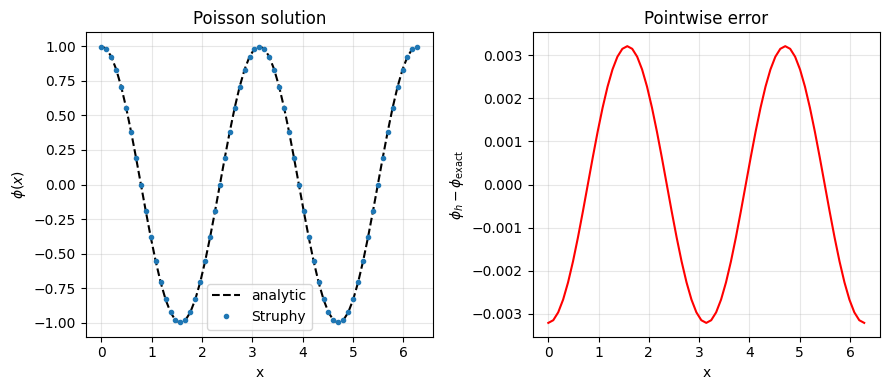

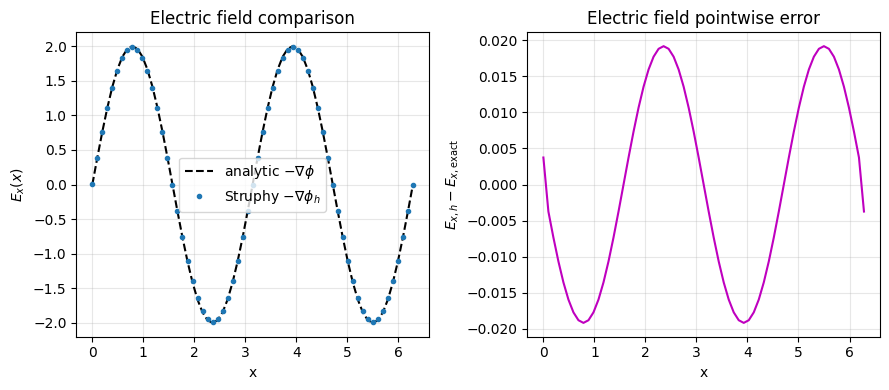

In [4]:
# Extract 1D line data and compare to analytic solution
x = sim.grids_phy[0][:, 0, 0]

t_last = max(sim.spline_values.em_fields.phi_log.data.keys())
phi_num = sim.spline_values.em_fields.phi_log.data[t_last][0][:, 0, 0]
phi_ref = phi_exact(x, 0.0, 0.0)

err = phi_num - phi_ref
err_max = np.max(np.abs(err))

plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.plot(x, phi_ref, "k--", label="analytic")
plt.plot(x, phi_num, "o", ms=3, label="Struphy")
plt.xlabel("x")
plt.ylabel(r"$\phi(x)$")
plt.title("Poisson solution")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(x, err, "r", lw=1.5)
plt.xlabel("x")
plt.ylabel(r"$\phi_h - \phi_\mathrm{exact}$")
plt.title("Pointwise error")
plt.grid(alpha=0.3)

plt.tight_layout()
print(f"max-norm error ||phi_h - phi_exact||_inf = {err_max:.3e}")

# Electric field comparison: E = -grad(phi)
E_num = -np.gradient(phi_num, x, edge_order=2)
E_ref = k * np.sin(k * x)
E_err = E_num - E_ref
E_err_max = np.max(np.abs(E_err))

plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.plot(x, E_ref, "k--", label=r"analytic $-\nabla\phi$")
plt.plot(x, E_num, "o", ms=3, label=r"Struphy $-\nabla\phi_h$")
plt.xlabel("x")
plt.ylabel(r"$E_x(x)$")
plt.title("Electric field comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(x, E_err, "m", lw=1.5)
plt.xlabel("x")
plt.ylabel(r"$E_{x,h} - E_{x,\mathrm{exact}}$")
plt.title("Electric field pointwise error")
plt.grid(alpha=0.3)

plt.tight_layout()
print(f"max-norm error ||E_h - E_exact||_inf = {E_err_max:.3e}")

## 2D Manufactured Test on a Rectangle

We now solve a **2D Poisson problem on a rectangular domain** with different side lengths. This tests:
- Multi-dimensional elliptic solves
- Non-square domains
- Homogeneous Dirichlet (zero) boundary conditions

The rectangular domain is:

$$
(x,y) \in [0,L_x] \times [0,L_y], \quad L_x \neq L_y.
$$

We choose a separable manufactured solution that vanishes on all four boundaries:

$$
\phi_\mathrm{exact}(x,y) = \sin\left(\frac{2\pi x}{L_x}\right)\sin\left(\frac{2\pi y}{L_y}\right).
$$

For the Poisson equation $-\Delta\phi + \varepsilon\phi = \rho$, the required manufactured source is:

$$
\rho(x,y) = \left[\left(\frac{2\pi}{L_x}\right)^2 + \left(\frac{2\pi}{L_y}\right)^2 + \varepsilon\right] \phi_\mathrm{exact}(x,y).
$$

Unlike the periodic case, we now enforce **Dirichlet boundary conditions** ($\phi = 0$ on all boundaries).
The solution is unique without any stabilization ($\varepsilon$ can be very small).

We construct this 2D test through model perturbations (`ModesSinSin`) and compare solution fields at select points using contour plots.

In [5]:
# 2D manufactured Poisson setup and solve
Lx2 = 2.0
Ly2 = 1.0
eps2 = 1e-8

kx2 = 2.0 * np.pi / Lx2
ky2 = 2.0 * np.pi / Ly2

phi2_exact = lambda e1, e2, e3: np.sin(kx2 * e1) * np.sin(ky2 * e2)

model2 = Poisson()
model2.propagators.poisson.options = model2.propagators.poisson.Options(
    stab_eps=eps2,
    )

source_amp2 = kx2**2 + ky2**2 + eps2
model2.em_fields.source.add_perturbation(
    perturbations.ModesSinSin(ls=(1,), ms=(1,), amps=(source_amp2,))
    )

domain2 = domains.Cuboid(l1=0.0, r1=Lx2, l2=0.0, r2=Ly2)
grid2 = grids.TensorProductGrid(num_elements=(48, 32, 1))
derham_opts2 = DerhamOptions(
    degree=(3, 3, 1),
    bcs=(("dirichlet", "dirichlet"), ("dirichlet", "dirichlet"), None),
    )

sim2 = Simulation(
    model=model2,
    domain=domain2,
    grid=grid2,
    derham_opts=derham_opts2,
    )

sim2.run(one_time_step=True)
sim2.pproc()
sim2.load_plotting_data()


Starting run for model Poisson ...


Time stepping:   0%|          | 0/1 [00:00<?, ?step/s]

Time stepping: 100%|██████████| 1/1 [00:00<00:00, 80.17step/s]


Struphy run finished.



Post-processing path /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_1


...


self.spline_values:


    em_fields
        phi_log
        source_log



self.orbits:


self.f:


self.n_sph:


2D max-norm error ||phi_h - phi_exact||_inf = 1.589e-07


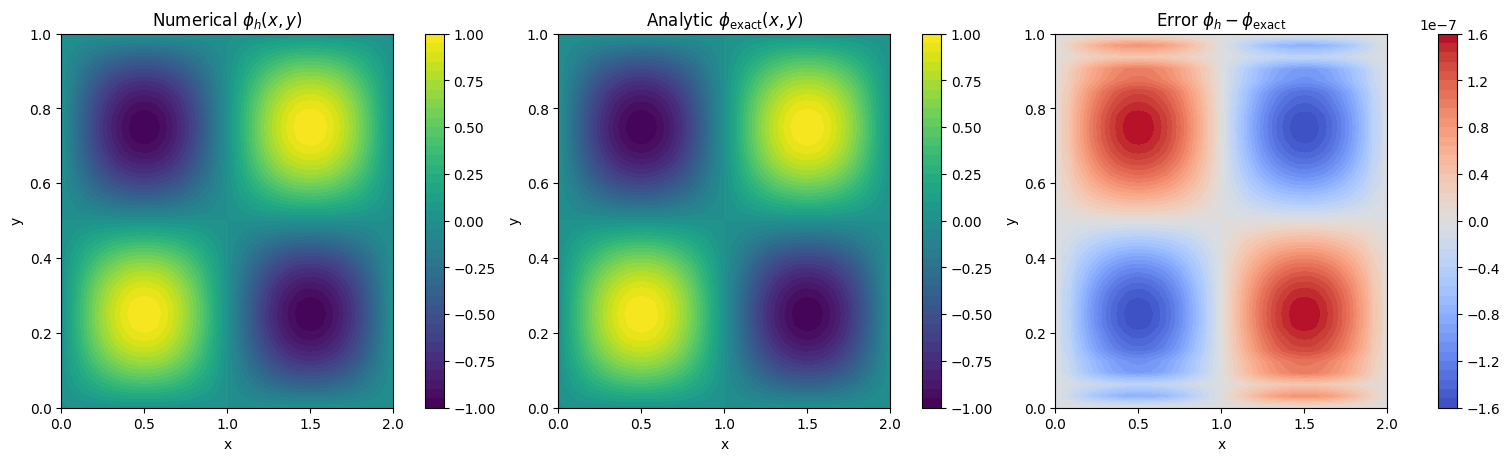

In [6]:
# 2D diagnostics and plots
t2_last = max(sim2.spline_values.em_fields.phi_log.data.keys())
X = sim2.grids_phy[0][:, :, 0]
Y = sim2.grids_phy[1][:, :, 0]

phi2_num = sim2.spline_values.em_fields.phi_log.data[t2_last][0][:, :, 0]
phi2_ref = phi2_exact(X, Y, 0.0)
err2 = phi2_num - phi2_ref
err2_max = np.max(np.abs(err2))

fig, axs = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

im0 = axs[0].contourf(X, Y, phi2_num, levels=40, cmap="viridis")
axs[0].set_title("Numerical $\\phi_h(x,y)$")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].contourf(X, Y, phi2_ref, levels=40, cmap="viridis")
axs[1].set_title("Analytic $\\phi_{\\mathrm{exact}}(x,y)$")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
plt.colorbar(im1, ax=axs[1])

im2 = axs[2].contourf(X, Y, err2, levels=40, cmap="coolwarm")
axs[2].set_title("Error $\\phi_h-\\phi_{\\mathrm{exact}}$")
axs[2].set_xlabel("x")
axs[2].set_ylabel("y")
plt.colorbar(im2, ax=axs[2])

print(f"2D max-norm error ||phi_h - phi_exact||_inf = {err2_max:.3e}")

## 2D Manufactured Test on a Thin Annulus (Polar Coordinates)

As a second 2D geometry test, we solve Poisson on a **thin annulus** (a disc-shaped domain with a small hole).
This demonstrates:
- Non-Cartesian geometries (polar coordinates via conformal mapping)
- Dirichlet boundary conditions at both inner and outer radii
- Manufactured solutions expressed in polar coordinates

The geometry is a thin annulus with radii $a_1 < r < a_2$. We use the manufactured solution in polar coordinates $(r, \theta)$:

$$
\phi_\mathrm{exact}(r,\theta) = \sin\left(\pi\frac{r-a_1}{a_2-a_1}\right)\sin(m\theta),
$$

where $m$ is an azimuthal mode number. This solution automatically satisfies:
- **Inner boundary** ($r=a_1$): $\phi = 0$ (since $\sin(0) = 0$)
- **Outer boundary** ($r=a_2$): $\phi = 0$ (since $\sin(\pi) = 0$)

The source term $\rho$ is computed analytically in polar coordinates, accounting for the Laplacian in polar form:

$$
\Delta\phi = \frac{d^2\phi}{dr^2} + \frac{1}{r}\frac{d\phi}{dr} + \frac{1}{r^2}\frac{d^2\phi}{d\theta^2}.
$$

This manufactured solution is injected via a `GenericPerturbation` directly in physical space.
Plots are shown in physical $(x,y)$ coordinates for visualization.

In [7]:
# HollowCylinder manufactured annulus test (physical-space definition)
a1 = 0.8
a2 = 1.0
Lz3 = 1.0
m3 = 3
eps3 = 1e-8
w3 = a2 - a1
alpha3 = np.pi / w3

def phi3_exact(x, y, z):
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    s = alpha3 * (r - a1)
    return np.sin(s) * np.sin(m3 * theta)

def rho3_exact(x, y, z):
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    s = alpha3 * (r - a1)

    sin_s = np.sin(s)
    cos_s = np.cos(s)
    sin_mt = np.sin(m3 * theta)

    # -Delta(phi) + eps*phi for phi(r,theta)=sin(s)sin(m theta)
    term = (alpha3**2) * sin_s - (alpha3 / r) * cos_s + (m3**2 / r**2) * sin_s + eps3 * sin_s
    return term * sin_mt

model3 = Poisson()
model3.propagators.poisson.options = model3.propagators.poisson.Options(
    stab_eps=eps3,
    )

model3.em_fields.source.add_perturbation(
    GenericPerturbation(rho3_exact, given_in_basis="physical")
    )

domain3 = domains.HollowCylinder(a1=a1, a2=a2, Lz=Lz3)
grid3 = grids.TensorProductGrid(num_elements=(36, 96, 1))
derham_opts3 = DerhamOptions(
    degree=(3, 3, 1),
    bcs=(("dirichlet", "dirichlet"), None, None),
    )

sim3 = Simulation(
    model=model3,
    domain=domain3,
    grid=grid3,
    derham_opts=derham_opts3,
    )

sim3.run(one_time_step=True)
sim3.pproc()
sim3.load_plotting_data()


Starting run for model Poisson ...


Time stepping:   0%|          | 0/1 [00:00<?, ?step/s]

Time stepping: 100%|██████████| 1/1 [00:00<00:00, 65.35step/s]


Struphy run finished.



Post-processing path /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_1


...


self.spline_values:


    em_fields
        phi_log
        source_log



self.orbits:


self.f:


self.n_sph:


Annulus max-norm error ||phi_h - phi_exact||_inf = 1.101e-05


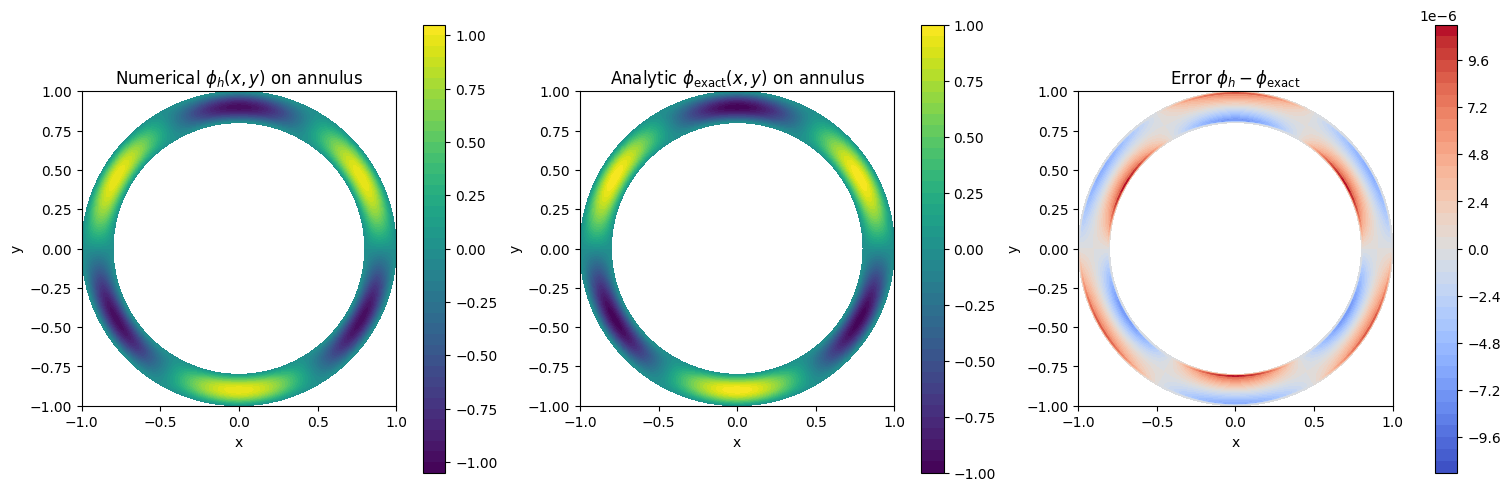

In [8]:
# Annulus diagnostics and plots in physical coordinates only
t3_last = max(sim3.spline_values.em_fields.phi_log.data.keys())
X3 = sim3.grids_phy[0][:, :, 0]
Y3 = sim3.grids_phy[1][:, :, 0]

phi3_num = sim3.spline_values.em_fields.phi_log.data[t3_last][0][:, :, 0]
phi3_ref = phi3_exact(X3, Y3, 0.0)
err3 = phi3_num - phi3_ref
err3_max = np.max(np.abs(err3))

fig3, axs3 = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)

im30 = axs3[0].contourf(X3, Y3, phi3_num, levels=40, cmap="viridis")
axs3[0].set_title("Numerical $\\phi_h(x,y)$ on annulus")
axs3[0].set_xlabel("x")
axs3[0].set_ylabel("y")
axs3[0].set_aspect("equal")
plt.colorbar(im30, ax=axs3[0])

im31 = axs3[1].contourf(X3, Y3, phi3_ref, levels=40, cmap="viridis")
axs3[1].set_title("Analytic $\\phi_{\\mathrm{exact}}(x,y)$ on annulus")
axs3[1].set_xlabel("x")
axs3[1].set_ylabel("y")
axs3[1].set_aspect("equal")
plt.colorbar(im31, ax=axs3[1])

im32 = axs3[2].contourf(X3, Y3, err3, levels=40, cmap="coolwarm")
axs3[2].set_title("Error $\\phi_h-\\phi_{\\mathrm{exact}}$")
axs3[2].set_xlabel("x")
axs3[2].set_ylabel("y")
axs3[2].set_aspect("equal")
plt.colorbar(im32, ax=axs3[2])

print(f"Annulus max-norm error ||phi_h - phi_exact||_inf = {err3_max:.3e}")

## 1D Time-Dependent Source Test Case

So far we have solved stationary Poisson problems where the source term is independent of time.
Now we consider a **time-dependent source** where the right-hand side of the Poisson equation evolves in time.

This scenario arises in many applications, such as:
- Plasma physics simulations where the source term varies with time due to wave activity
- Electromagnetic problems with oscillating charge or current distributions
- Coupled multiphysics systems where sources depend on time-evolving quantities

### Mathematical Setup

We solve the time-dependent Poisson equation on a 1D periodic domain with a **sinusoidal source**:

$$
-\phi'' + \varepsilon\phi = \rho(x,t),
$$

where the manufactured source is:

$$
\rho(x,t) = A\cos\left(kx\right)\cos(\omega t),
$$

with wavenumber $k$, spatial amplitude $A$, and angular frequency $\omega$.

The exact solution is:

$$
\phi_\mathrm{exact}(x,t) = \frac{A}{k^2 + \varepsilon}\cos(kx)\cos(\omega t).
$$

The source varies periodically in time, and the solution follows this oscillation. We use Struphy's `TimeDependentSource` propagator to evolve both the source and the solution over multiple time steps, comparing numerical and exact solutions at each time.

In [9]:
# Time-dependent source setup
# Parameters: domain extent, wavenumber, frequency, and stabilization
Lx4 = 10.0  # Domain: x in [-Lx4/2, Lx4/2]
l4 = 2      # Wavenumber mode: k = 2*pi*l/Lx
k4 = l4 * 2.0 * np.pi / Lx4
omega4 = 2.0 * np.pi  # Angular frequency (one period in [0,1] of normalized time)
amp4 = 0.1  # Spatial amplitude of source
eps4 = 1e-8  # Tiny stabilization for periodic domain

# Create a Poisson model with time-dependent source enabled
model4 = Poisson(with_t_dep_source=True)

# Configure the time-dependent source propagator with the frequency
model4.propagators.source.options = model4.propagators.source.Options(omega=omega4)

# Configure the Poisson solver: set the source field as the RHS
model4.propagators.poisson.options = model4.propagators.poisson.Options(
    stab_eps=eps4,
)

# Initialize the source with a cosine perturbation
# The source will be: rho(x,t) = amp * cos(k*x) * cos(omega*t)
model4.em_fields.source.add_perturbation(
    perturbations.ModesCos(ls=(l4,), amps=(amp4,))
)

# Define exact solutions for comparison
def rho4_exact(x, t):
    """Exact time-dependent source: amplitude * cos(kx) * cos(omega*t)"""
    return amp4 * np.cos(k4 * x) * np.cos(omega4 * t)

def phi4_exact(x, t):
    """Exact solution: (amplitude / k^2) * cos(kx) * cos(omega*t)"""
    # The Poisson equation -phi'' + eps*phi = rho has solution
    # phi(x,t) = rho(x,t) / (k^2 + eps) for this cosine mode
    return (amp4 / (k4**2 + eps4)) * np.cos(k4 * x) * np.cos(omega4 * t)

In [10]:
# Set up domain, grid, and simulation for time-dependent case
l1_4 = -Lx4 / 2.0
r1_4 = Lx4 / 2.0
domain4 = domains.Cuboid(l1=l1_4, r1=r1_4)

# Use a moderate grid resolution for reasonable compute time
grid4 = grids.TensorProductGrid(num_elements=(48, 1, 1))

# Time stepping: evolve from t=0 to t=2.0 with dt=0.1 (20 time steps)
# This covers 2 full periods of oscillation (since omega = 2*pi)
from struphy import Time
time_opts4 = Time(dt=0.1, Tend=2.0)

derham_opts4 = DerhamOptions()

# Create and run the simulation
sim4 = Simulation(
    model=model4,
    domain=domain4,
    grid=grid4,
    derham_opts=derham_opts4,
    time_opts=time_opts4,
)

# Run the full time-dependent simulation
sim4.run()
sim4.pproc()
sim4.load_plotting_data()


Starting run for model Poisson ...


Time stepping:   0%|          | 0/20 [00:00<?, ?step/s]

Time stepping: 100%|██████████| 20/20 [00:00<00:00, 191.70step/s]

Time stepping: 100%|██████████| 20/20 [00:00<00:00, 183.83step/s]


Struphy run finished.


...


self.spline_values:


    em_fields
        phi_log
        source_log



self.orbits:


self.f:


self.n_sph:


Solution saved at 21 time points
Global max-norm error: 3.604e-04
Relative error: 5.692e-03 (normalized by solution amplitude 6.333e-02)


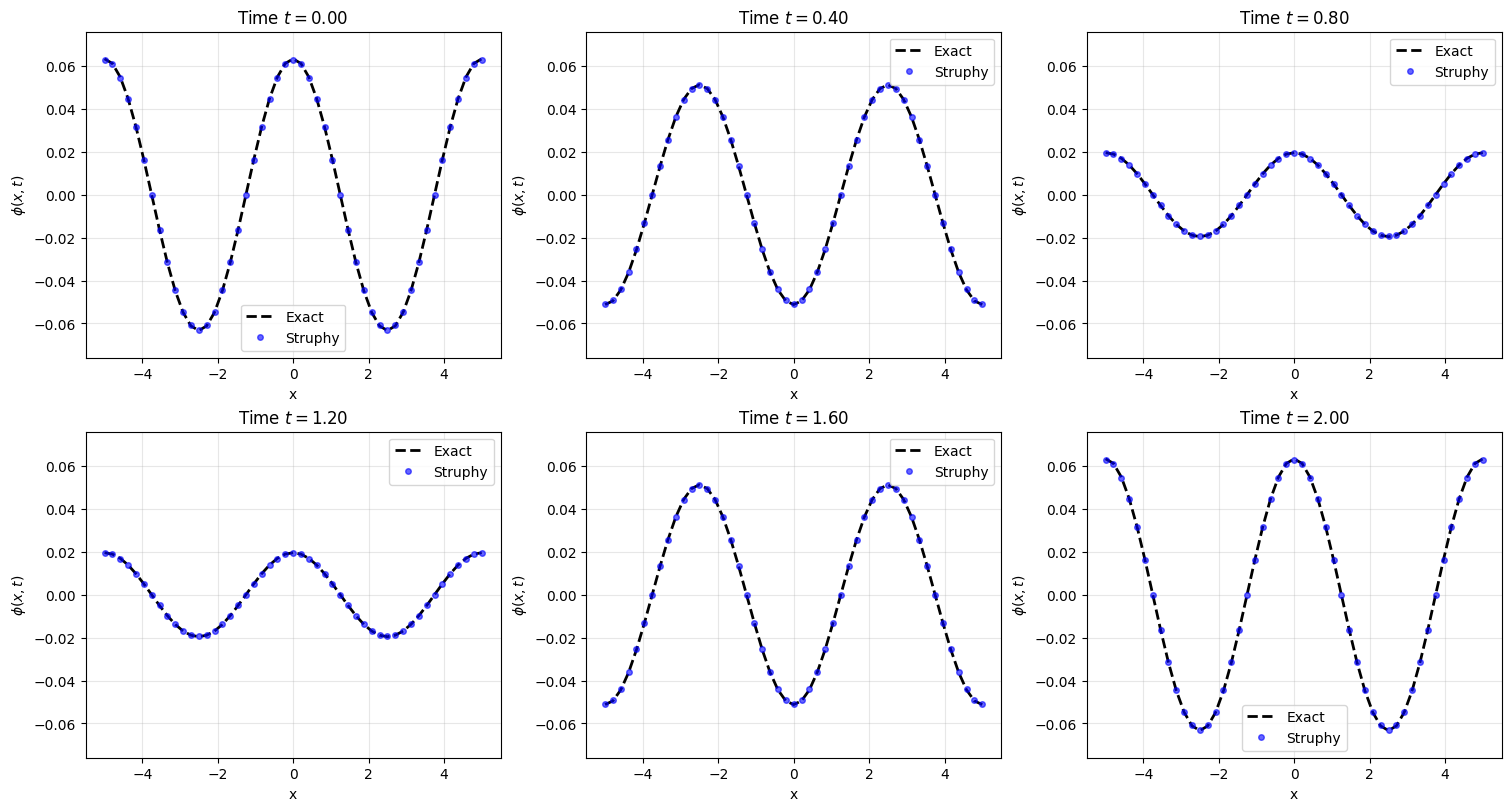

In [11]:
# Extract and visualize time-dependent results
x4 = sim4.grids_phy[0][:, 0, 0]
phi4_log = sim4.spline_values.em_fields.phi_log.data
source4_log = sim4.spline_values.em_fields.source_log.data
t_times = sorted(phi4_log.keys())

print(f"Solution saved at {len(t_times)} time points")

# Compute maximum error over all time steps
err_max_global = 0.0
for t in t_times:
    phi_h = phi4_log[t][0][:, 0, 0]  # Numerical solution
    phi_e = phi4_exact(x4, t)         # Exact solution
    err_local = np.max(np.abs(phi_h - phi_e))
    if err_local > err_max_global:
        err_max_global = err_local

# Normalize by the solution amplitude for a relative error measure
phi_amplitude = amp4 / (k4**2 + eps4)
rel_err = err_max_global / phi_amplitude

print(f"Global max-norm error: {err_max_global:.3e}")
print(f"Relative error: {rel_err:.3e} (normalized by solution amplitude {phi_amplitude:.3e})")

# Create time snapshots at select time steps
fig_snaps, axs_snaps = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
axs_snaps = axs_snaps.flatten()

select_times = [t_times[i] for i in [0, len(t_times)//5, 2*len(t_times)//5, 
                                      3*len(t_times)//5, 4*len(t_times)//5, -1]]

for idx, t in enumerate(select_times):
    ax = axs_snaps[idx]
    
    phi_num = phi4_log[t][0][:, 0, 0]
    phi_ref = phi4_exact(x4, t)
    
    ax.plot(x4, phi_ref, "k--", linewidth=2, label="Exact")
    ax.plot(x4, phi_num, "bo", markersize=4, alpha=0.6, label="Struphy")
    ax.set_xlabel("x")
    ax.set_ylabel(r"$\phi(x,t)$")
    ax.set_title(f"Time $t = {t:.2f}$")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim(-phi_amplitude * 1.2, phi_amplitude * 1.2)

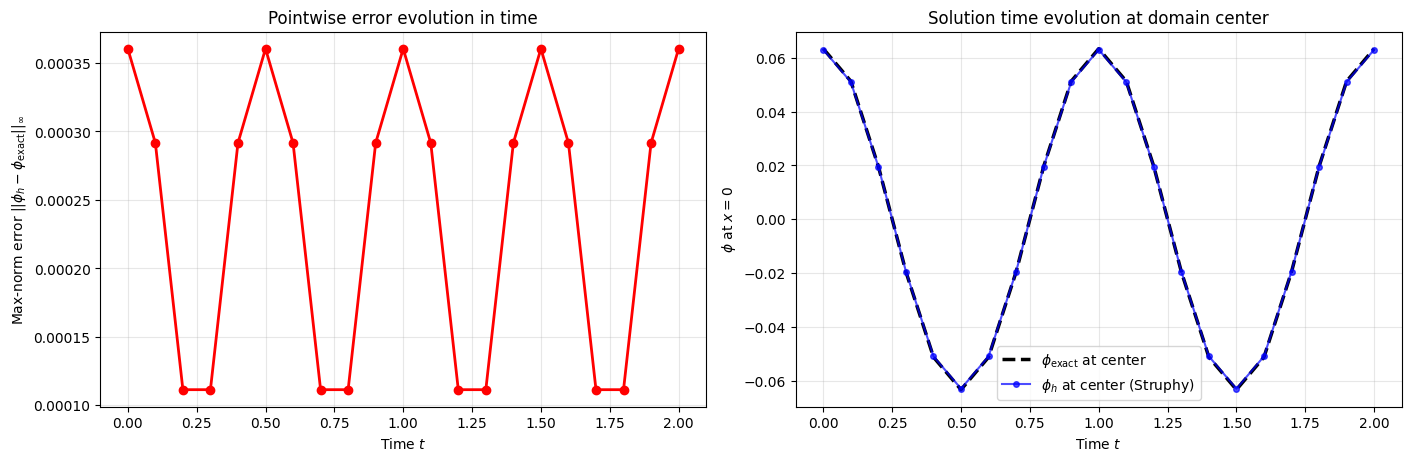

In [12]:
# Plot error evolution over time
fig_err, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

errors = []
times_array = np.array(t_times)
for t in t_times:
    phi_h = phi4_log[t][0][:, 0, 0]
    phi_e = phi4_exact(x4, t)
    err = np.max(np.abs(phi_h - phi_e))
    errors.append(err)

ax1.plot(times_array, errors, "ro-", linewidth=2, markersize=6)
ax1.set_xlabel("Time $t$")
ax1.set_ylabel("Max-norm error $||\\phi_h - \\phi_{\\mathrm{exact}}||_\\infty$")
ax1.set_title("Pointwise error evolution in time")
ax1.grid(alpha=0.3)

# Plot source and solution at a single point in space (center)
center_idx = len(x4) // 2
phi_center = [phi4_log[t][0][center_idx, 0, 0] for t in t_times]
phi_exact_center = [phi4_exact(x4[center_idx], t) for t in t_times]
source_center = [source4_log[t][0][center_idx, 0, 0] for t in t_times]
source_exact_center = [rho4_exact(x4[center_idx], t) for t in t_times]

ax2.plot(times_array, phi_exact_center, "k--", linewidth=2.5, label="$\\phi_{\\mathrm{exact}}$ at center")
ax2.plot(times_array, phi_center, "bo-", markersize=4, alpha=0.7, label="$\\phi_h$ at center (Struphy)")
ax2.set_xlabel("Time $t$")
ax2.set_ylabel(r"$\phi$ at $x = 0$")
ax2.set_title("Solution time evolution at domain center")
ax2.legend()
ax2.grid(alpha=0.3)